In [8]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["total_column_water"],
    "year": ["2012"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "netcdf",
    "download_format": "zip",
    "area": [33.5, 78.5, 32, 79.5]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


ModuleNotFoundError: No module named 'cdsapi'

In [2]:
!pip install numpy pandas matplotlib xarray netCDF4

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 23.2 MB/s  0:00:00
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   ------------ --------------------------- 6.8/21.3 MB 37.0 MB/s eta 0:00:01
   ---------------------------- ----------- 15.2/21.3 MB 37.6 MB/s eta 0:00:01
   ---------------------------------------  21.2/21.3 MB 37.6 MB/s eta 0:00:01
   ---------------------------------------- 21.3/21.3 MB 34.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [netCDF4]
   ------------- -------------------------- 1/3 [netCDF4]
   ------------- -------------------------- 1/3 [netCDF4]
   -------------------------- ------------- 2/3 [xarray]
   -------------------------- ------------- 2/3 [xarray]
   -------------------------- ------------- 2/3 [xarray]
   -------------------------- ------------- 2/3 [xarray]
   -------------------------- ------------- 2/3 [xarray]
   ------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import xarray as xr

ds = xr.open_dataset("data_stream-oper_stepType-instant.nc")

print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 8784, latitude: 7, longitude: 5)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2012-01-01 ... 2012-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 56B 33.5 33.25 33.0 32.75 32.5 32.25 32.0
  * longitude   (longitude) float64 40B 78.5 78.75 79.0 79.25 79.5
    number      int64 8B ...
Data variables:
    tcw         (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-23T10:42 GRIB to CDM+CF via cfgrib-0.9.1...


In [12]:
pwv_era5 = ds["tcw"]
time_era5 = ds["valid_time"]

In [13]:
print(pwv_era5)
print(time_era5)

<xarray.DataArray 'tcw' (valid_time: 8784, latitude: 7, longitude: 5)> Size: 1MB
[307440 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2012-01-01 ... 2012-12-31T23...
    expver      (valid_time) <U4 141kB ...
  * latitude    (latitude) float64 56B 33.5 33.25 33.0 32.75 32.5 32.25 32.0
  * longitude   (longitude) float64 40B 78.5 78.75 79.0 79.25 79.5
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             136
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      35
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2
    long_name:                                Total column water
    units:                      

In [14]:
pwv_pixel = pwv_era5[:, 3, 2]

In [15]:
import pandas as pd

era5_df = pd.DataFrame({
    "time": time_era5.values,
    "pwv_era5": pwv_pixel.values
})

In [17]:
print(ds["latitude"])
print(ds["longitude"])

<xarray.DataArray 'latitude' (latitude: 7)> Size: 56B
array([33.5 , 33.25, 33.  , 32.75, 32.5 , 32.25, 32.  ])
Coordinates:
  * latitude  (latitude) float64 56B 33.5 33.25 33.0 32.75 32.5 32.25 32.0
    number    int64 8B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing
<xarray.DataArray 'longitude' (longitude: 5)> Size: 40B
array([78.5 , 78.75, 79.  , 79.25, 79.5 ])
Coordinates:
  * longitude  (longitude) float64 40B 78.5 78.75 79.0 79.25 79.5
    number     int64 8B ...
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude


In [20]:
pip install --upgrade pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------------ --------------- 6.0/9.9 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 39.6 MB/s  0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.0
    Uninstalling pandas-3.0.0:
      Successfully uninstalled pandas-3.0.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd

hanle = pd.read_csv(
    "pwv_hanle.dat",
    sep=r"\s+",          # Use regex for whitespace instead of delim_whitespace
    comment="#",
    names=["year","doy","hour","minute","second","pwv"]
)

print(hanle.head())

   year  doy  hour  minute  second   pwv
0  2008   65     2       0     0.0  1.71
1  2008   65     4       0     0.0  1.83
2  2008   66     2       0     0.0  2.88
3  2008   67     2       0     0.0  2.79
4  2008   67     4       0     0.0  2.95


In [26]:
hanle["time"] = pd.to_datetime(
    hanle["year"].astype(str) + "-" + hanle["doy"].astype(str),
    format="%Y-%j"
) + pd.to_timedelta(hanle["hour"], unit="h")

In [31]:
# Convert year + DOY + hour to datetime
hanle["time"] = pd.to_datetime(
    hanle["year"].astype(str) + "-" + hanle["doy"].astype(str),
    format="%Y-%j"
) + pd.to_timedelta(hanle["hour"], unit="h")

# Keep only necessary columns
hanle_df = hanle[["time","pwv"]].rename(columns={"pwv":"pwv_hanle"})

# Round to the hour to align timestamps with ERA5
hanle_df["time"] = hanle_df["time"].dt.floor("h")

In [32]:
merged = pd.merge(
    era5_df,
    hanle_df,
    on="time",
    how="left"  # missing Hanle data becomes NaN
)

print(merged.head())

                 time  pwv_era5  pwv_hanle
0 2012-01-01 00:00:00  1.547283        NaN
1 2012-01-01 01:00:00  1.437212        NaN
2 2012-01-01 02:00:00  1.325547       2.77
3 2012-01-01 03:00:00  1.207200        NaN
4 2012-01-01 04:00:00  1.158986       2.03


In [34]:
# ERA5
era5_df["time"] = pd.to_datetime(era5_df["time"]).dt.floor("h")

# Hanle
hanle_df["time"] = pd.to_datetime(hanle_df["time"]).dt.floor("h")

In [35]:
merged = pd.merge(
    era5_df,
    hanle_df,
    on="time",
    how="left"
)

In [36]:
print(merged["pwv_hanle"].isna().sum())
print(merged["pwv_hanle"].notna().sum())

7259
1525


In [38]:
# Set index to time
hanle_df.set_index("time", inplace=True)
# Resample hourly, interpolate missing
hanle_df_hourly = hanle_df.resample("h").mean().reset_index()

# Merge again
merged = pd.merge(
    era5_df,
    hanle_df_hourly,
    on="time",
    how="left"
)

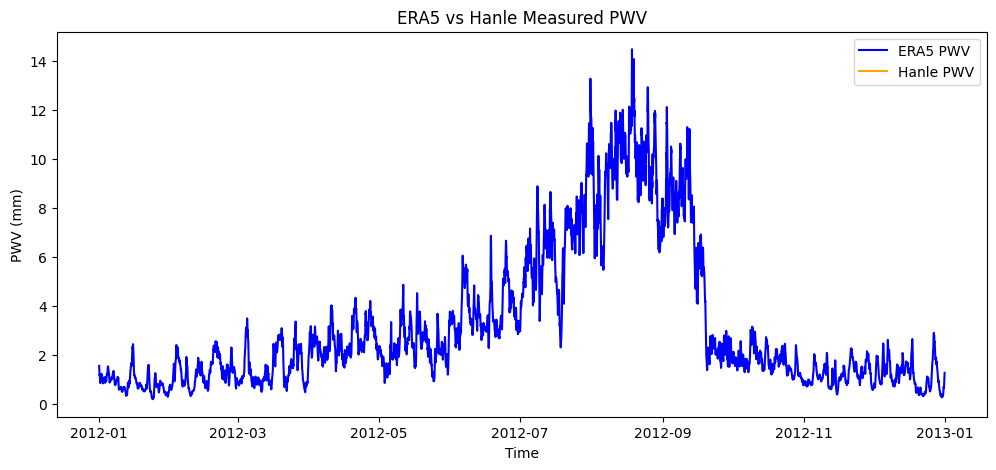

In [39]:
plt.figure(figsize=(12,5))
plt.plot(merged["time"], merged["pwv_era5"], label="ERA5 PWV", color="blue")
plt.plot(merged["time"], merged["pwv_hanle"], label="Hanle PWV", color="orange")
plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("ERA5 vs Hanle Measured PWV")
plt.legend()
plt.show()

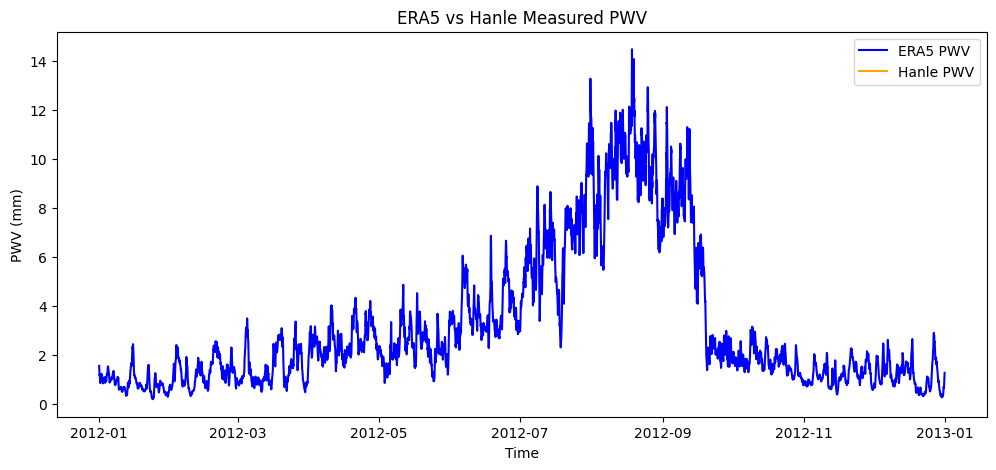

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
# Set index
hanle_df.set_index("time", inplace=True)

# Reindex to ERA5 times
hanle_interp = hanle_df.reindex(era5_df["time"]).interpolate(method="time").reset_index()
hanle_interp.rename(columns={"index":"time","pwv_hanle":"pwv_hanl
# Merge
merged_interp = pd.merge(
    era5_df,
    hanle_interp,
    on="time",
    how="left"
)
plt.plot(merged["time"], merged["pwv_era5"], label="ERA5 PWV", color="blue")
plt.plot(merged["time"], merged["pwv_hanle"], label="Hanle PWV", color="orange")

plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("ERA5 vs Hanle Measured PWV")
plt.legend()
plt.show()